## Document Loaders

RAG : RAG is a technique that combines information retrieval with language generation where a model retrieves relevant document from a knowledge base and then uses them as context to generate accuraate and grounded responses

## Benefits
1. up-do-data information
2. privacy
3. No limit of document size

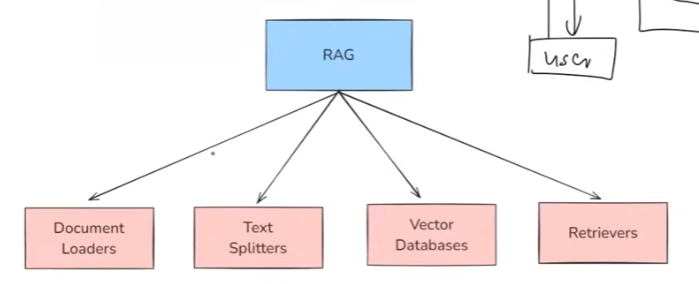

## This is video of Document Loaders

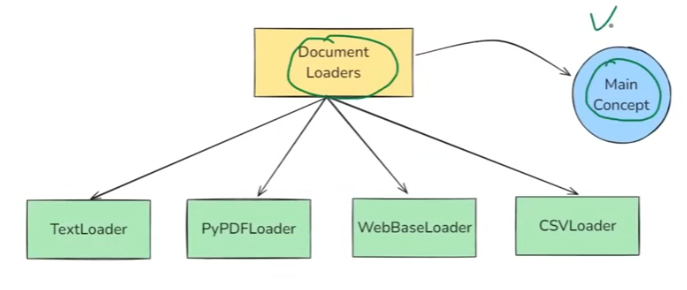

### Document Loadeers in LangChain

Document loaders are components in langchain used to load data from various sources into a standardized format (usuallu as Document objects), which can then be used for chunking, embedding, retrieval and generation

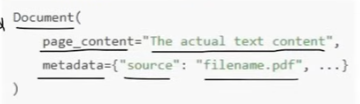

## 1. TextLoader

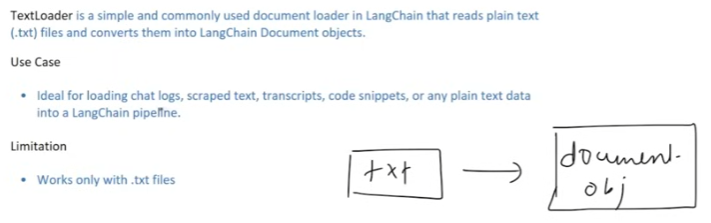

In [14]:
from langchain_community.document_loaders import TextLoader
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableLambda

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

prompt = PromptTemplate(
    template = "Write a summary of the following text {text}",
    input_variables = ['text']
)

parser = StrOutputParser()

loader = TextLoader('cricket.txt', encoding = 'utf-8')

docs = loader.load()

# print(docs[0].page_content)
# print(docs[0].metadata)

chain = prompt | model | parser

result = chain.invoke({'text' : docs[0].page_content})
print(result)

Cricket is an integral part of Indian culture, evoking strong emotions among millions of fans across the country. The sport is played between two teams of eleven players, with the objective of scoring more runs than the opponent. The excitement of T20 cricket, combined with leagues like the Indian Premier League (IPL), has brought international and local talent together. Cricket teaches valuable life lessons such as teamwork, patience, discipline, and leadership, making it a beloved game for fans of all ages. With its unique blend of skill, strategy, and emotion, cricket continues to grow in popularity, with every match offering a thrilling experience for fans who celebrate the game as a celebration with family and friends.


## 2. pyPDFLoader

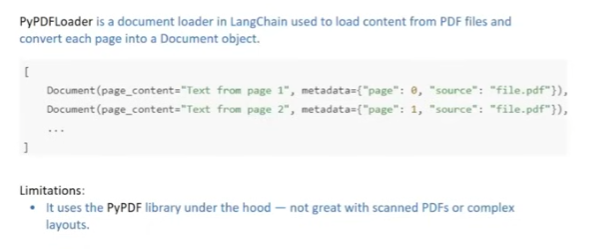

You get page wise content

In [15]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableLambda
from langchain_community.document_loaders import PyPDFLoader
# Its same as textLoader,

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

this loader wont work good on scanned images pdf, this will work baest for textual data, u have other loader for other types

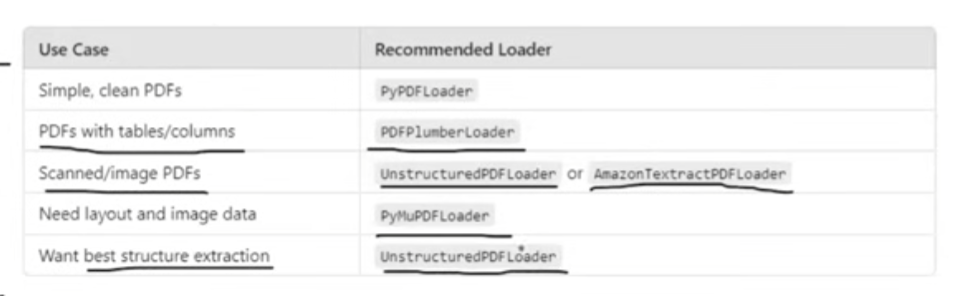

### 3. Directory Loader

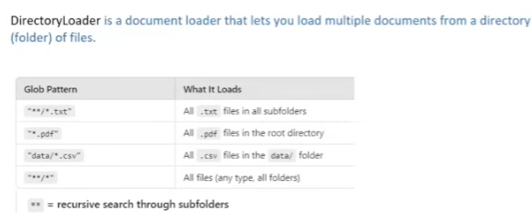

In [ ]:
from langchain_community.document_loaders import DirectoryLoader, PyPDFLoader

loader = DirectoryLoader(
    path = 'books',
    glob = '*.pdf',
    loader_cls = PyPDFLoader
)

docs = loader.load()

You are loading all the content in the RAM at a time, if there is huge data, there can be problem due to these storage issue etc

So to avoid this huge loading in RAM and it take time, there is solution for this

## Lazy_load

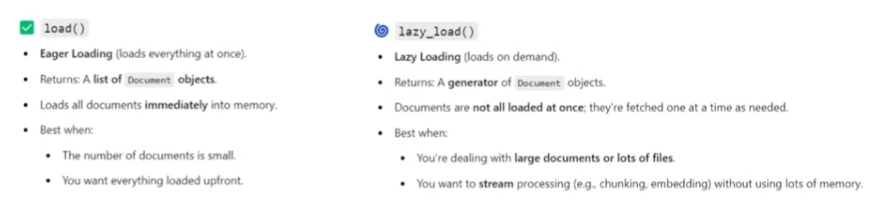

## 4. WebBaseLoader

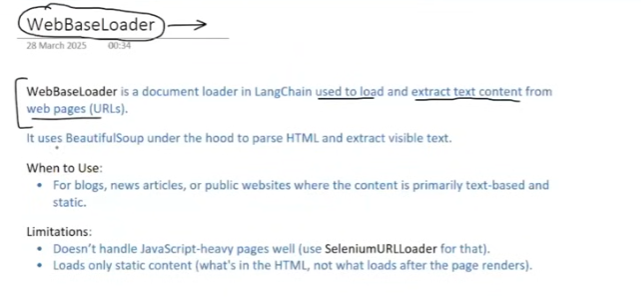

## 5. CSVLoader

## U can make custom Document Loader